In [1]:
import matplotlib.pyplot as plt
import gymnasium as gym
import numpy as np
import matplotlib
import time
from dataclasses import dataclass

In [2]:
rng = np.random.default_rng(seed = 42)

### Initializing the Custom Grid 4x4 Environment

In [3]:
class CustomGridWorld:
    def __init__(self, rows=4,cols=4,start_state=(0,0),terminal_states=None,obstacles=None,step_reward=-0.03,terminal_rewards=None,
    gamma=0.99,stochastic=False,intended_prob=0.8):
        self.rows = rows
        self.cols = cols
        self.nS = rows * cols
        self.nA = 4
        self.start_state = start_state
        self.start_index = self.to_state(start_state) 
        self.terminal_states = terminal_states if terminal_states else {(rows -1, cols -1)}
        self.obstacles = obstacles if obstacles else set()
        self.step_reward = step_reward
        self.terminal_rewards = terminal_rewards if terminal_rewards else {(rows-1,cols-1):1.0}
        self.gamma = gamma
        self.stochastic = stochastic
        self.intended_prob = intended_prob


        self.actions = {
            0: (-1,0),
            1: (1,0),
            2: (0,-1),
            3: (0,1)
        }

        self.prependicular = {
            0: [2,3],
            1: [2,3],
            2: [0,1],
            3: [0,1]
        }

        self.P = self.build_transition_model()
        self.reset()



    def to_state(self,start_position):
        r,c = start_position
        return r * self.cols + c

    def to_pos(self, state):
        return (state // self.cols, state % self.cols)

    def is_terminal(self,state):
        return self.to_pos(state) in self.terminal_states    
    
    def is_obstacle(self,state):
        return self.to_pos(state) in self.obstacles

    def valid_position(self, r,c):
        if not (0 <= r < self.rows and 0 <=c < self.cols):
            return False
        if (r,c) in self.obstacles:
            return False
        return True
    
    def move(self,state, action):
        if self.is_terminal(state):
            return state
        r,c = self.to_pos(state)
        dr, dc = self.actions[action]
        nr, nc = r + dr, c + dc

        if not self.valid_position(nr, nc):
            return state
        return self.to_state((nr, nc))
    
    def get_rewards(self, next_state):
        pos = self.to_pos(next_state) 
        if pos in self.terminal_rewards:
            return self.terminal_rewards[pos]
        return self.step_reward
    
    def build_transition_model(self):
        P = {s: {a:[] for a in range(self.nA)} for s in range(self.nS)}
        for s in range(self.nS):
            if self.is_obstacle(s):
                continue
            for a in range(self.nA):
                if self.is_terminal(s):
                    P[s][a] = [(1.0,s,0.0,True)]
                    continue
                transitions = {}

                if self.stochastic:
                    side_probability = (1.0 - self.intended_prob) /2.0
                    candidates = [
                        (self.intended_prob, a),
                        (side_probability, self.prependicular[a][0]),
                        (side_probability, self.prependicular[a][1]),
                    ]
                else:
                    candidates = [(1.0,a)]
                
                for prob,actual_action in candidates:
                    ns = self.move(s, actual_action)
                    reward = self.get_rewards(ns)
                    done = self.is_terminal(ns)

                    key = (ns, reward, done)
                    transitions[key] = transitions.get(key, 0.0) + prob
                P[s][a] = [(prob, ns, r, done) for (ns, r, done), prob in transitions.items()]
        return P

    def reset(self):
        self.state = self.start_index
        return self.state, {}
    
    def step(self, action):
        transitions = self.P[self.state][action]
        probs = [t[0] for t in transitions]
        idx = np.random.choice(len(transitions), p=probs)
        prob, next_state, reward, done = transitions[idx]
        self.state = next_state
        return next_state,reward,done,False,{}
        

In [24]:
deterministic_env = CustomGridWorld(rows=4, cols=4, obstacles={(1,1)}, terminal_states={(3,3)}, stochastic=False)
stochastic_env = CustomGridWorld(rows=4, cols=4, obstacles={(1,1)}, terminal_states={(3,3)}, stochastic=True)

dV = np.zeros(deterministic_env.nS)
sV = np.zeros(stochastic_env.nS)

### Plotting Helpers

In [25]:
ACTION_ARROWS = {
    0 : (0,-1),
    1 : (0,1),
    2 : (-1,0),
    3 : (1,0),
}

ACTION_TEXT = {
    0 : "UP",
    1 : "DOWN",
    2: "LEFT",
    3: "RIGTH",
}

### Plotting Heatmap

In [26]:
def value_iteration(P, nS, nA, gamma=0.99, theta=1e-6, max_iterations=1000):
    V = np.zeros(nS)
    value_history = [V.copy()]
    deltas = []

    for iteration in range(max_iterations):
        delta = 0
        V_new = np.zeros_like(V)

        for s in range(nS):
            action_values = []

            for a in range(nA):
                total = 0

                for prob, next_state, reward, done in P[s][a]:
                    if done:
                        total += prob * reward
                    else:
                        total += prob * (reward + gamma * V[next_state])

                action_values.append(total)

            V_new[s] = max(action_values)
            delta = max(delta, abs(V_new[s] - V[s]))

        V = V_new
        value_history.append(V.copy())
        deltas.append(delta)

        if delta < theta:
            break

    policy = np.zeros(nS, dtype=int)

    for s in range(nS):
        action_values = []

        for a in range(nA):
            total = 0

            for prob, next_state, reward, done in P[s][a]:
                if done:
                    total += prob * reward
                else:
                    total += prob * (reward + gamma * V[next_state])

            action_values.append(total)

        policy[s] = np.argmax(action_values)

    return {
        "V": V,
        "policy": policy,
        "value_history": value_history,
        "deltas": deltas,
        "iterations": len(deltas)
    }

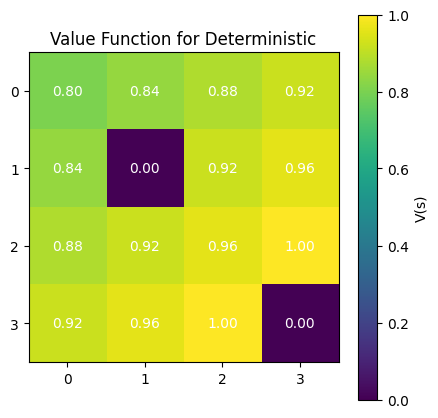

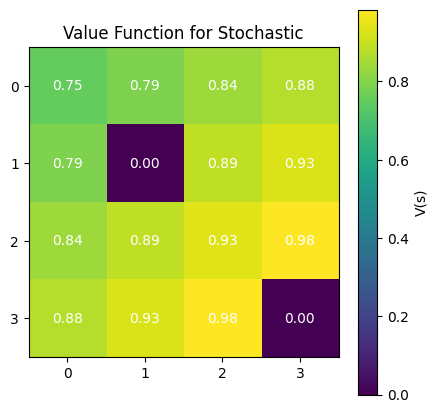

In [37]:
def plot_value_heatmap(V, rows, cols, title="Value Function"):
    grid = V.reshape(rows, cols)
    plt.figure(figsize=(5, 5))
    plt.imshow(grid, cmap="viridis")
    plt.colorbar(label="V(s)")
    for r in range(rows):
        for c in range(cols):
            plt.text(c, r, f"{grid[r, c]:.2f}", ha="center", va="center", color="white")
    plt.title(title)
    plt.xticks(range(cols))
    plt.yticks(range(rows))
    plt.show()

Dvi_results = value_iteration(deterministic_env.P,deterministic_env.nS,deterministic_env.nA, gamma=0.99, theta=1e-6)
Svi_results = value_iteration(stochastic_env.P,stochastic_env.nS,stochastic_env.nA, gamma=0.99, theta=1e-6)
plot_value_heatmap(Dvi_results["V"],deterministic_env.rows,deterministic_env.cols, title="Value Function for Deterministic")
plot_value_heatmap(Svi_results["V"],stochastic_env.rows,stochastic_env.cols, title="Value Function for Stochastic")

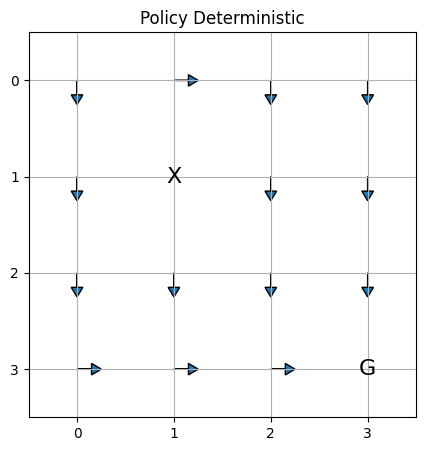

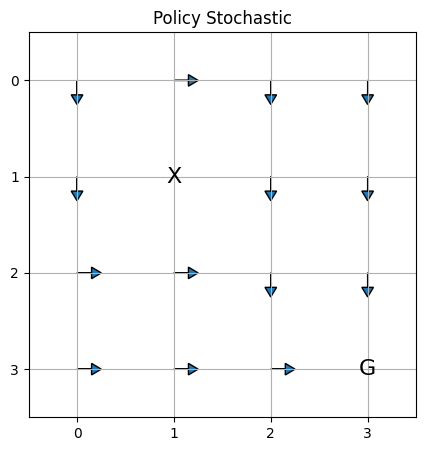

In [35]:
def plot_policy(policy, env, title="Policy"):
    plt.figure(figsize=(5, 5))
    plt.xlim(-0.5, env.cols - 0.5)
    plt.ylim(env.rows - 0.5, -0.5)
    plt.xticks(range(env.cols))
    plt.yticks(range(env.rows))
    plt.grid()

    for s in range(env.nS):
        r, c = env.to_pos(s)

        if (r, c) in env.obstacles:
            plt.text(c, r, "X", ha="center", va="center", fontsize=16)
            continue
        if (r, c) in env.terminal_states:
            plt.text(c, r, "G", ha="center", va="center", fontsize=16)
            continue

        a = policy[s]
        dx, dy = ACTION_ARROWS[a]
        plt.arrow(c, r, 0.25 * dx, 0.25 * dy, head_width=0.12, head_length=0.1, length_includes_head=True)

    plt.title(title)
    plt.show()
plot_policy(Dvi_results["policy"], deterministic_env,title="Policy Deterministic")
plot_policy(Svi_results["policy"],stochastic_env, title="Policy Stochastic")

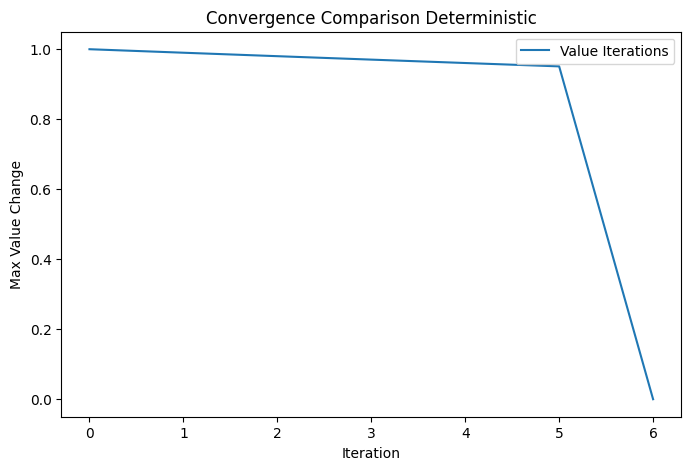

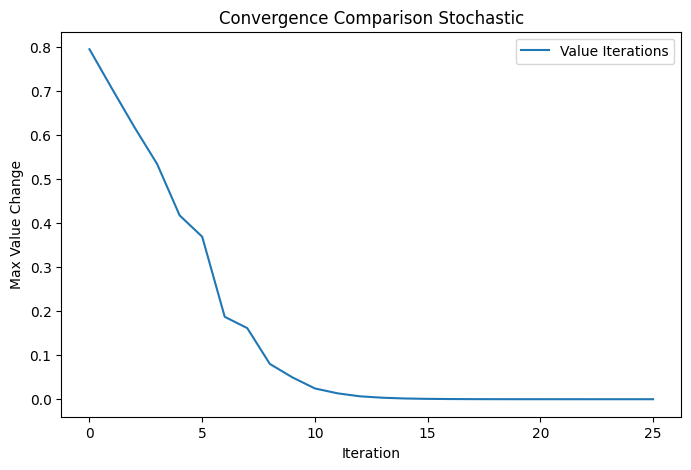

In [36]:
def plot_convergence(curves, title="Convergence Comparison"):
    plt.figure(figsize=(8, 5))
    for label, values in curves.items():
        plt.plot(values, label=label)
    plt.xlabel("Iteration")
    plt.ylabel("Max Value Change")
    plt.title(title)
    plt.legend()
    plt.show()

def plot_env(env, title="GridWorld"):
    plt.figure(figsize=(5, 5))
    plt.xlim(-0.5, env.cols - 0.5)
    plt.ylim(env.rows - 0.5, -0.5)
    plt.xticks(range(env.cols))
    plt.yticks(range(env.rows))
    plt.grid()

    agent_pos = env.to_pos(env.state)

    for s in range(env.nS):
        r, c = env.to_pos(s)

        if (r, c) in env.obstacles:
            plt.text(c, r, "X", ha="center", va="center", fontsize=16)
        elif (r, c) in env.terminal_states:
            plt.text(c, r, "G", ha="center", va="center", fontsize=16)
        elif (r, c) == agent_pos:
            plt.text(c, r, "A", ha="center", va="center", fontsize=16)
        else:
            plt.text(c, r, ".", ha="center", va="center", fontsize=12)

    plt.title(title)
    plt.show()


plot_convergence({"Value Iterations": Dvi_results["deltas"]},title="Convergence Comparison Deterministic")
plot_convergence({"Value Iterations": Svi_results['deltas']},title="Convergence Comparison Stochastic")

### Frozen Lake Implementation

In [39]:
Dfrozen_lake = gym.make("FrozenLake-v1", is_slippery=False)
Sfrozen_lake = gym.make("FrozenLake-v1",is_slippery=True)

In [42]:
Pdet = Dfrozen_lake.unwrapped.P
Psto = Sfrozen_lake.unwrapped.P
nS_det = Dfrozen_lake.observation_space.n
nS_sto = Sfrozen_lake.observation_space.n
nA_det = Dfrozen_lake.action_space.n
nA_sto = Sfrozen_lake.action_space.n

In [43]:
Dvi_results_frozen = value_iteration(Pdet,nS_det,nA_det,gamma=0.99,theta=1e-6)
Svi_results_frozen = value_iteration(Psto,nS_sto,nA_sto, gamma=0.99,theta=1e-6)

Plotting the same graphs but for the Frozen Lake Implementation

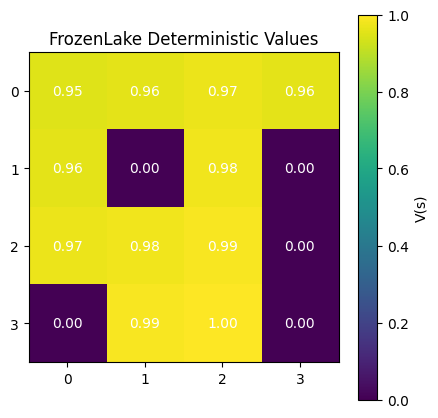

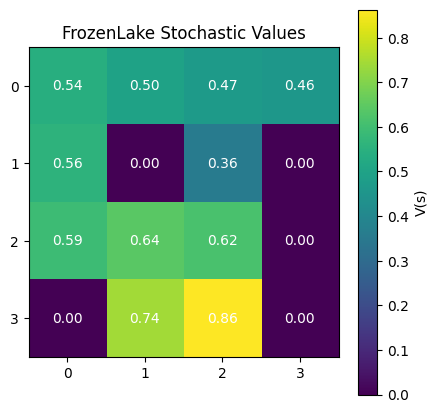

In [48]:
plot_value_heatmap(Dvi_results_frozen["V"],4,4,"FrozenLake Deterministic Values")
plot_value_heatmap(Svi_results_frozen["V"],4,4,"FrozenLake Stochastic Values")

In [57]:
def plot_policy_frozen(policy, env, title="FrozenLake Policy"):
    size = int(np.sqrt(len(policy)))
    desc = env.unwrapped.desc  # map layout

    plt.figure(figsize=(5, 5))
    plt.xlim(-0.5, size - 0.5)
    plt.ylim(size - 0.5, -0.5)
    plt.xticks(range(size))
    plt.yticks(range(size))
    plt.grid()

    ACTION_ARROWS_FL = {
        0: (-1, 0),  # Left
        1: (0, 1),   # Down
        2: (1, 0),   # Right
        3: (0, -1),  # Up
    }

    for s in range(len(policy)):
        r = s // size
        c = s % size

        cell = desc[r][c].decode("utf-8")

        # Draw map elements
        if cell == "H":
            plt.text(c, r, "H", ha="center", va="center", fontsize=14)
            continue
        elif cell == "G":
            plt.text(c, r, "G", ha="center", va="center", fontsize=14)
            continue
        elif cell == "S":
            plt.text(c, r, "S", ha="center", va="center", fontsize=14)

        # Draw arrow
        a = policy[s]
        dx, dy = ACTION_ARROWS_FL[a]

        plt.arrow(c, r, 0.25 * dx, 0.25 * dy,
                  head_width=0.12, head_length=0.1,
                  length_includes_head=True)

    plt.title(title)
    plt.show()

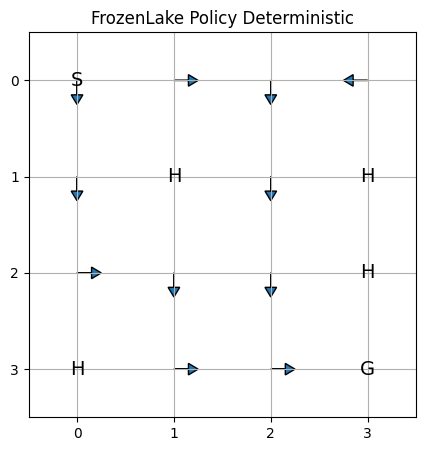

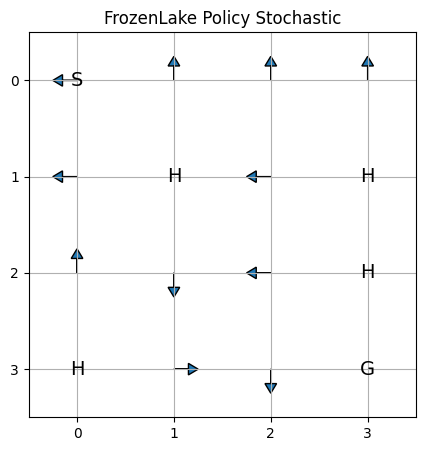

In [58]:
plot_policy_frozen(Dvi_results_frozen["policy"],Dfrozen_lake,title="FrozenLake Policy Deterministic")
plot_policy_frozen(Svi_results_frozen["policy"], Sfrozen_lake,title="FrozenLake Policy Stochastic")

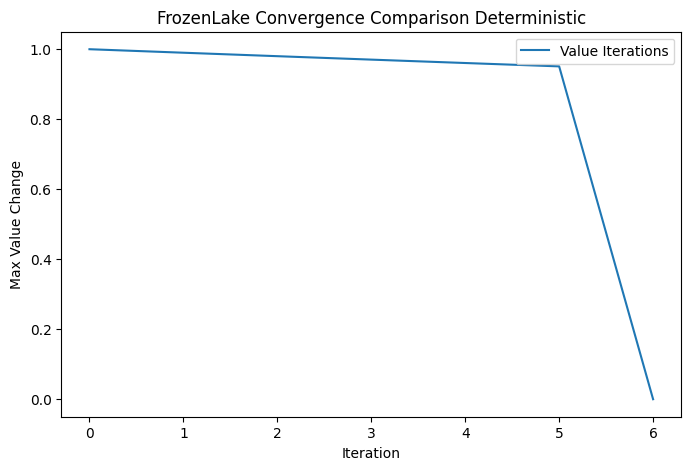

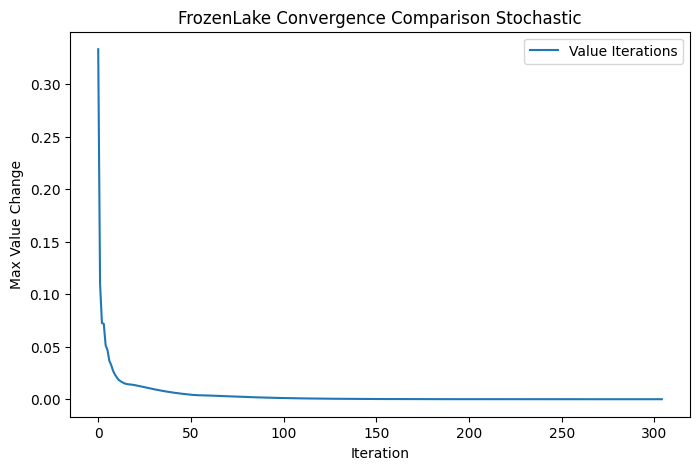

In [59]:
plot_convergence({"Value Iterations": Dvi_results_frozen["deltas"]},title="FrozenLake Convergence Comparison Deterministic")
plot_convergence({"Value Iterations": Svi_results_frozen['deltas']},title="FrozenLake Convergence Comparison Stochastic")